# Hospital Patient Care Analytics Pipeline

## Case Study

A multi-specialty hospital collects data from different systems such as:

- Patient registration
- Appointment scheduling
- Laboratory reports
- Wearable health devices
- Doctor consultation notes

The hospital wants to use this data to improve patient care, understand waiting time, and identify patients who may need more attention.



## Dataset

For this Casestudy, I am using five CSV files:

- `patients.csv`
- `appointments.csv`
- `lab_reports.csv`
- `wearable_data.csv`
- `consultations.csv`



 

# Module 1 – Import Libraries

I import the libraries required for reading, analyzing and visualizing the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### Summary:-

First, I imported Pandas, NumPy, Matplotlib and Seaborn. Pandas is used for data handling, NumPy for simple calculations, and Matplotlib and Seaborn for charts.

# Module 2 – Data Ingestion
Read the CSV Files

I read all the hospital datasets using `pd.read_csv()`.

In [2]:
patients = pd.read_csv("data/patients.csv")
appointments = pd.read_csv("data/appointments.csv")
labs = pd.read_csv("data/lab_reports.csv")
wearable = pd.read_csv("data/wearable_data.csv")
consultations = pd.read_csv("data/consultations.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


### Summary

I loaded five CSV files. Each file contains a different type of hospital information. I keep them separate first and combine them later using patient ID. 

# Module 3 – Data Understanding
Inspect the Data

Before changing the data, I first understand what is inside it.

I use:
- `head()` to see the first rows.
- `info()` to check columns and data types.
- `describe()` to see basic numerical information.
- `isnull().sum()` to find missing values.

In [3]:
patients.head()

,patient_id,patient_name,age,gender,blood_group
0,P1001,Patient_1,56,Male,B+
1,P1002,Patient_2,69,Female,AB+
2,P1003,Patient_3,46,Male,A+
3,P1004,Patient_4,32,Male,AB+
4,P1005,Patient_5,60,Male,B+


In [4]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   patient_id    30 non-null     object
 1   patient_name  30 non-null     object
 2   age           30 non-null     int64 
 3   gender        30 non-null     object
 4   blood_group   30 non-null     object
dtypes: int64(1), object(4)
memory usage: 1.3+ KB


In [5]:
patients.describe()

,age
count,30.000000
mean,43.433333
std,14.991223
min,19.000000
25%,33.000000
50%,41.000000
75%,55.750000
max,70.000000


In [6]:
print("Missing values in patients:")
print(patients.isnull().sum())

Missing values in patients:
patient_id      0
patient_name    0
age             0
gender          0
blood_group     0
dtype: int64


In [7]:
print("Missing values in appointments:")
print(appointments.isnull().sum())

Missing values in appointments:
appointment_id        0
patient_id            0
appointment_date      0
department            0
appointment_status    0
waiting_time          0
dtype: int64


In [8]:
print("Missing values in laboratory data:")
print(labs.isnull().sum())

Missing values in laboratory data:
lab_id            0
patient_id        0
blood_sugar       0
hemoglobin        0
cholesterol       0
blood_pressure    0
dtype: int64


In [9]:
print("Missing values in wearable data:")
print(wearable.isnull().sum())

Missing values in wearable data:
wearable_id    0
patient_id     0
heart_rate     0
steps          0
sleep_hours    0
dtype: int64


In [10]:
print("Missing values in consultation data:")
print(consultations.isnull().sum())

Missing values in consultation data:
consultation_id      0
patient_id           0
doctor               0
diagnosis            0
consultation_date    0
dtype: int64


### Summary

I inspected the datasets before processing them. I checked the first rows, data types, basic statistics and missing values. This helps me understand the quality of the raw data.

# Module 4 – Data Cleaning
Clean the Data

 I will perform basic cleaning:

- remove duplicate rows,
- remove extra spaces from text,
- check missing values again.

In [12]:
patients = patients.drop_duplicates()
appointments = appointments.drop_duplicates()
labs = labs.drop_duplicates()
wearable = wearable.drop_duplicates()
consultations = consultations.drop_duplicates()

In [14]:
patients["gender"] = patients["gender"].str.strip()
patients["blood_group"] = patients["blood_group"].str.strip()
appointments["department"] = appointments["department"].str.strip()
appointments["appointment_status"] = appointments["appointment_status"].str.strip()
consultations["doctor"] = consultations["doctor"].str.strip()
consultations["diagnosis"] = consultations["diagnosis"].str.strip()

print("Data cleaning completed!")

Data cleaning completed!


In [15]:
print("Missing values after cleaning:")
print(patients.isnull().sum())

Missing values after cleaning:
patient_id      0
patient_name    0
age             0
gender          0
blood_group     0
dtype: int64


### Summary

I removed duplicate records and unnecessary spaces from text columns. I also checked the missing values again. Now the data is ready for combining and analysis.

# Module 5 – Combine the Hospital Data

Now I combine the different datasets.

All datasets contain `patient_id`, so I use it to connect the data.

In [16]:
hospital_data = patients.merge(
    appointments,
    on="patient_id",
    how="left"
)

hospital_data = hospital_data.merge(
    labs,
    on="patient_id",
    how="left"
)

hospital_data = hospital_data.merge(
    wearable,
    on="patient_id",
    how="left"
)

hospital_data = hospital_data.merge(
    consultations,
    on="patient_id",
    how="left"
)

print("All hospital datasets combined successfully!")

All hospital datasets combined successfully!


In [17]:
hospital_data.head()

,patient_id,patient_name,age,gender,blood_group,appointment_id,appointment_date,department,appointment_status,waiting_time,...,cholesterol,blood_pressure,wearable_id,heart_rate,steps,sleep_hours,consultation_id,doctor,diagnosis,consultation_date
0,P1001,Patient_1,56,Male,B+,A2001,2026-08-22,Cardiology,Completed,37,...,196,156,W4001,111,5487,6.9,C5001,Dr. Kumar,Diabetes Monitoring,2026-08-28
1,P1002,Patient_2,69,Female,AB+,A2002,2026-08-10,Dermatology,Cancelled,75,...,228,107,W4002,70,11219,6.1,C5002,Dr. Priya,Routine Checkup,2026-08-26
2,P1003,Patient_3,46,Male,A+,A2003,2026-08-04,Dermatology,Completed,51,...,189,147,W4003,108,7515,8.5,C5003,Dr. Kumar,Fever,2026-08-23
3,P1004,Patient_4,32,Male,AB+,A2004,2026-08-22,Dermatology,Completed,54,...,162,137,W4004,67,2718,8.0,C5004,Dr. Rao,Skin Allergy,2026-08-26
4,P1005,Patient_5,60,Male,B+,A2005,2026-08-29,Pediatrics,Completed,71,...,170,163,W4005,95,5996,8.8,C5005,Dr. Anil,Fever,2026-08-05


### Summary

I combined the five datasets using `patient_id`. This gives me one complete hospital dataset containing patient, appointment, laboratory, wearable and consultation information.

# Module 6 – Analyze Waiting Time

First, I calculate the average patient waiting time.

In [18]:
average_waiting_time = appointments["waiting_time"].mean()

print(
    "Average patient waiting time:",
    round(average_waiting_time, 2),
    "minutes"
)

Average patient waiting time: 53.63 minutes


### Waiting Time Distribution

This chart shows how the waiting time is distributed.

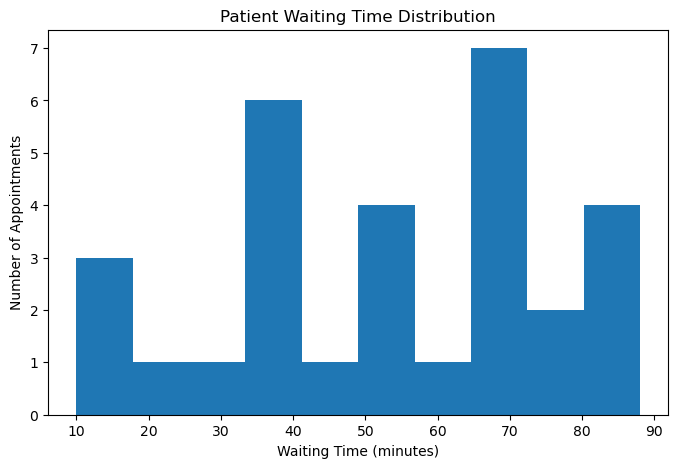

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(appointments["waiting_time"], bins=10)
plt.title("Patient Waiting Time Distribution")
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Number of Appointments")
plt.show()

### Average Waiting Time by Department

In [20]:
department_waiting = appointments.groupby(
    "department"
)["waiting_time"].mean()

print(department_waiting)

department
Cardiology          51.818182
Dermatology         60.500000
General Medicine    29.000000
Orthopedics         63.400000
Pediatrics          54.400000
Name: waiting_time, dtype: float64


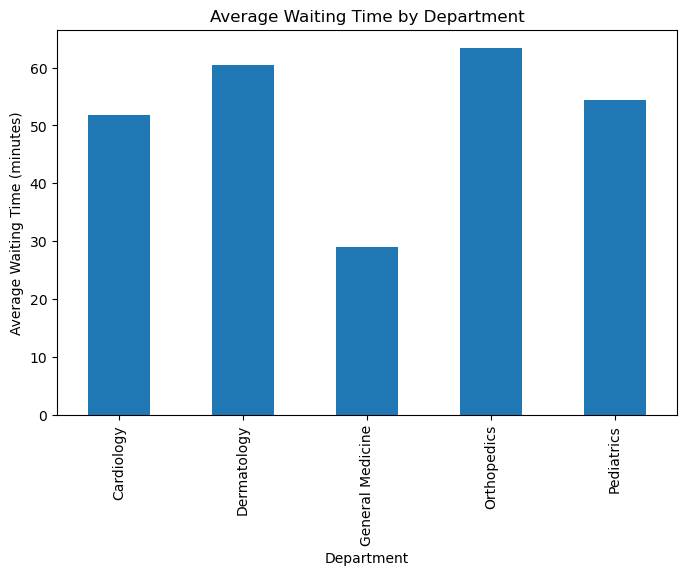

In [21]:
department_waiting.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (minutes)")

plt.show()

### Summary

I calculated the average waiting time and then checked the waiting time for each department. The charts help me understand which departments have higher or lower average waiting times. 

# Module 7 – Create a Simple Patient Risk Score

I created a **simple analytics score** using three measurements:

- Blood sugar
- Blood pressure
- Heart rate

If a value crosses the simple threshold used in this project, I add one point.


In [22]:
hospital_data["risk_score"] = 0

In [23]:
hospital_data.loc[
    hospital_data["blood_sugar"] > 140,
    "risk_score"
] += 1

hospital_data.loc[
    hospital_data["blood_pressure"] > 140,
    "risk_score"
] += 1

hospital_data.loc[
    hospital_data["heart_rate"] > 100,
    "risk_score"
] += 1

In [24]:
hospital_data["risk_level"] = np.where(
    hospital_data["risk_score"] >= 2,
    "High Risk",
    "Normal"
)

hospital_data["risk_level"].value_counts()

risk_level
Normal       20
High Risk    10
Name: count, dtype: int64

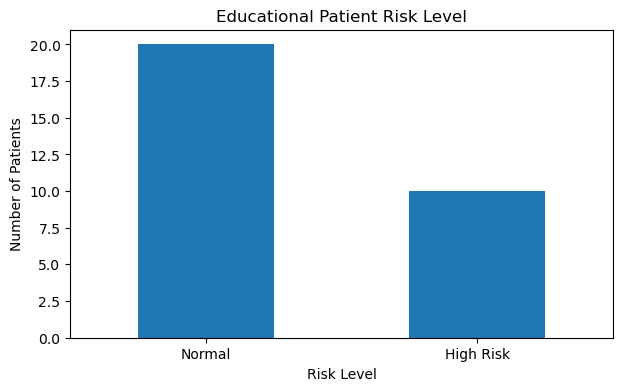

In [25]:
risk_counts = hospital_data["risk_level"].value_counts()
plt.figure(figsize=(7, 4))
risk_counts.plot(kind="bar")
plt.title("Educational Patient Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

### Summary

I created a simple risk score using three health measurements. Each measurement crossing the project threshold adds one point. Patients with two or more points are marked as High Risk for this analysis.

# Module 8 – Data Quality
Validate the Combined Data

Before exporting the data, I check whether the important IDs are connected correctly.

In [26]:
print("Number of patient records:", patients["patient_id"].nunique())
print("Number of combined records:", hospital_data["patient_id"].nunique())

print(
    "Missing patient IDs in combined data:",
    hospital_data["patient_id"].isnull().sum()
)

Number of patient records: 30
Number of combined records: 30
Missing patient IDs in combined data: 0


### Summary

I validated the combined data by checking the number of unique patients and checking whether patient IDs are missing. This helps confirm that the datasets were combined correctly.

# Module 9 – Export the Processed Data

Now I save the final processed dataset.

This file can later be loaded into a SQL database.

In [27]:
import os

os.makedirs("../output", exist_ok=True)

hospital_data.to_csv(
    "output/processed_patient_data.csv",
    index=False
)

print("Processed data saved successfully!")

Processed data saved successfully!


### Summary

After completing the cleaning, transformation and analysis, I exported the processed hospital data as a CSV file. This processed file is ready to be stored in a database. 

# Module 10 – Load the Processed Data into SQL

This is where the Python part connects with the SQL part.

The flow is:

**CSV → Python/Pandas → Clean & Transform → Processed CSV → SQL Database → SQL Analysis**


In [28]:
import sqlite3

connection = sqlite3.connect("output/hospital_patient_care.db")

hospital_data.to_sql(
    "hospital_data",
    connection,
    if_exists="replace",
    index=False
)

print("Processed data loaded into SQL successfully!")

Processed data loaded into SQL successfully!


### Summary

I loaded the final processed DataFrame into a SQL table. This means the data I cleaned and transformed in Jupyter is now stored in a database and can be analyzed using SQL.

# Module 11 – SQL Analysis

Now I use simple SQL queries on the database.

### Query 1 – Average Waiting Time

In [29]:
query = '''
SELECT AVG(waiting_time) AS average_waiting_time
FROM hospital_data;
'''

result = pd.read_sql_query(query, connection)

print(result)

   average_waiting_time
0             53.633333


### Query 2 – Average Waiting Time by Department

In [30]:
query = '''
SELECT
    department,
    AVG(waiting_time) AS average_waiting_time
FROM hospital_data
GROUP BY department;
'''

result = pd.read_sql_query(query, connection)

print(result)

         department  average_waiting_time
0        Cardiology             51.818182
1       Dermatology             60.500000
2  General Medicine             29.000000
3       Orthopedics             63.400000
4        Pediatrics             54.400000


### Query 3 – Number of Patients by Risk Level

In [31]:
query = '''
SELECT
    risk_level,
    COUNT(*) AS patient_count
FROM hospital_data
GROUP BY risk_level;
'''

result = pd.read_sql_query(query, connection)

print(result)

  risk_level  patient_count
0  High Risk             10
1     Normal             20


### Summary

After loading the data into SQL, I used simple SQL queries to calculate the average waiting time, compare departments and count patients by risk level. This completes the connection between Python data processing and SQL analysis.



## Complete Workflow

**Read CSV**  
↓  
**Inspect**  
↓  
**Clean**  
↓  
**Combine**  
↓  
**Transform**  
↓  
**Validate**  
↓  
**Analyze**  
↓  
**Export**  
↓  
**Load into SQL**  
↓  
**SQL Analysis**

### Final explanation

In this case study, I worked with hospital data from five different CSV files. First, I loaded the data using Pandas and inspected the datasets. Then I cleaned the data by removing duplicates and unnecessary spaces. After that, I combined all the datasets using patient ID. I calculated the average waiting time and analyzed waiting time department-wise. I also created a simple risk score using blood sugar, blood pressure and heart rate for educational analysis. Then I validated the combined data and exported the processed dataset. Finally, I loaded the processed data into SQL and used simple SQL queries for further analysis.

### Main methods I learned

- `pd.read_csv()` – read CSV
- `head()` – see first rows
- `info()` – check data types
- `describe()` – see basic statistics
- `isnull().sum()` – check missing values
- `drop_duplicates()` – remove duplicates
- `merge()` – combine datasets
- `mean()` – calculate average
- `groupby()` – group data
- `np.where()` – create a simple condition
- `to_csv()` – export data
- `to_sql()` – load data into SQL
- SQL `AVG()` – calculate average
- SQL `COUNT()` – count records
- SQL `GROUP BY` – group records